# BKG Studies

In [2]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate


In [3]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

In [4]:
# signals

sig_2mu = [
    "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",
    "2Mu2E_800GeV_5p0GeV_0p05mm",
    "2Mu2E_1000GeV_5p0GeV_0p04mm",
]

sig_4mu = [
    "4Mu_200GeV_5p0GeV_0p2mm",
    "4Mu_500GeV_5p0GeV_0p08mm",
    "4Mu_800GeV_5p0GeV_0p05mm",
    "4Mu_1000GeV_5p0GeV_0p04mm",
]

bkg = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    # "QCD_Pt800To1000",
    "QCD_Pt1000",       
]

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj"]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]

- ### 11: Adding photon cross cleaning and Switching to Dask. Running over all 2mu, all 4mu and 200 BKG files

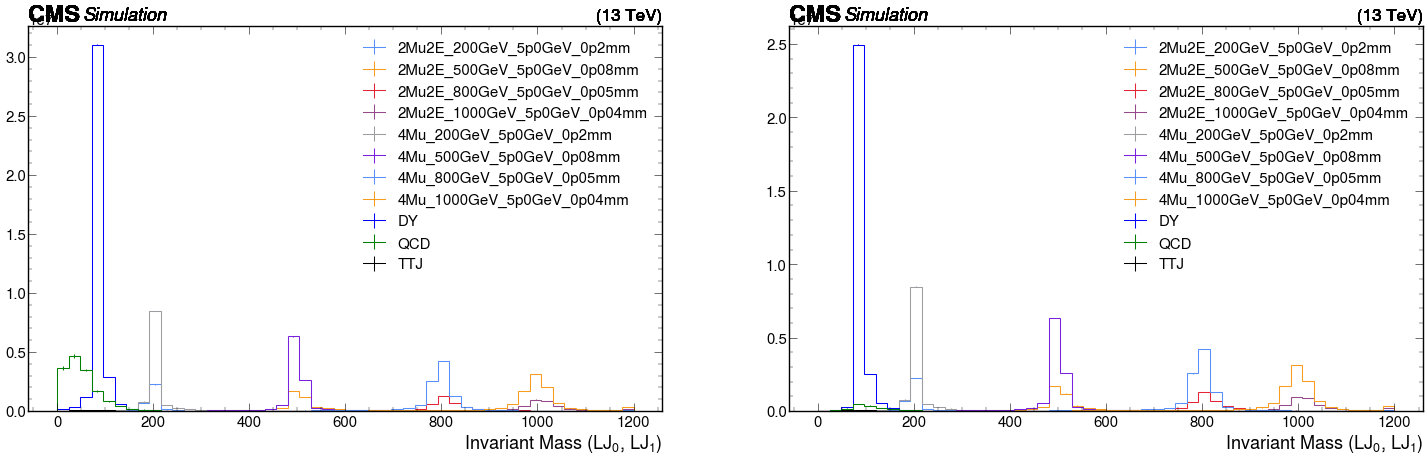

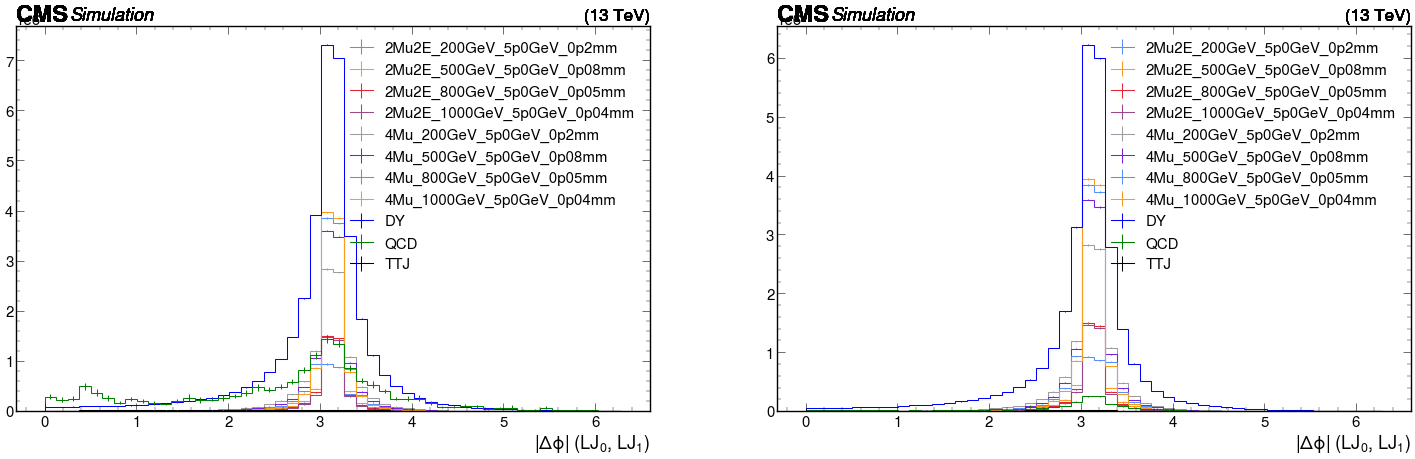

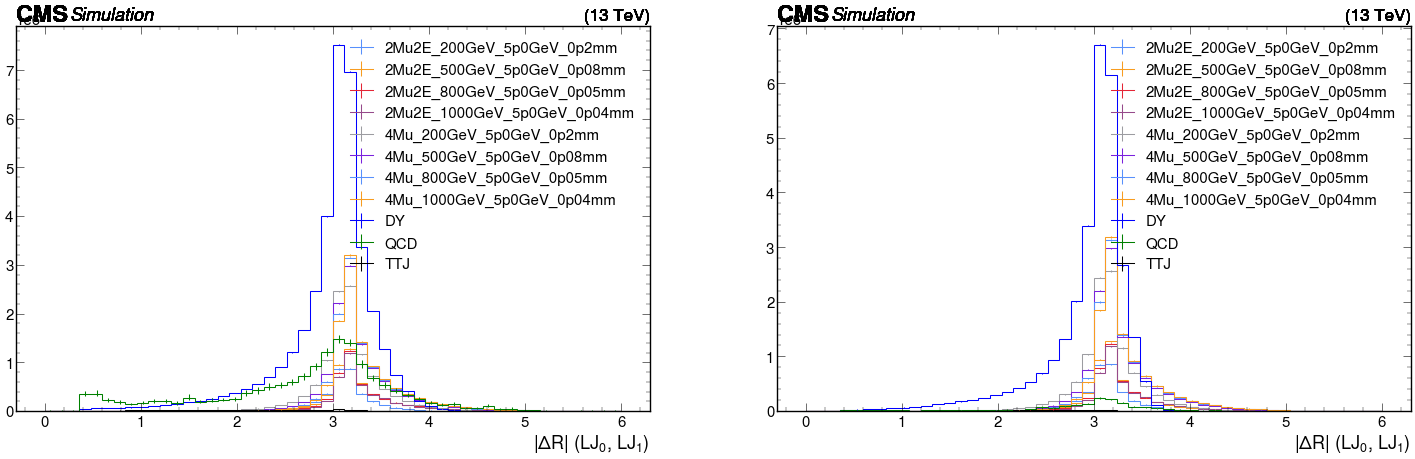

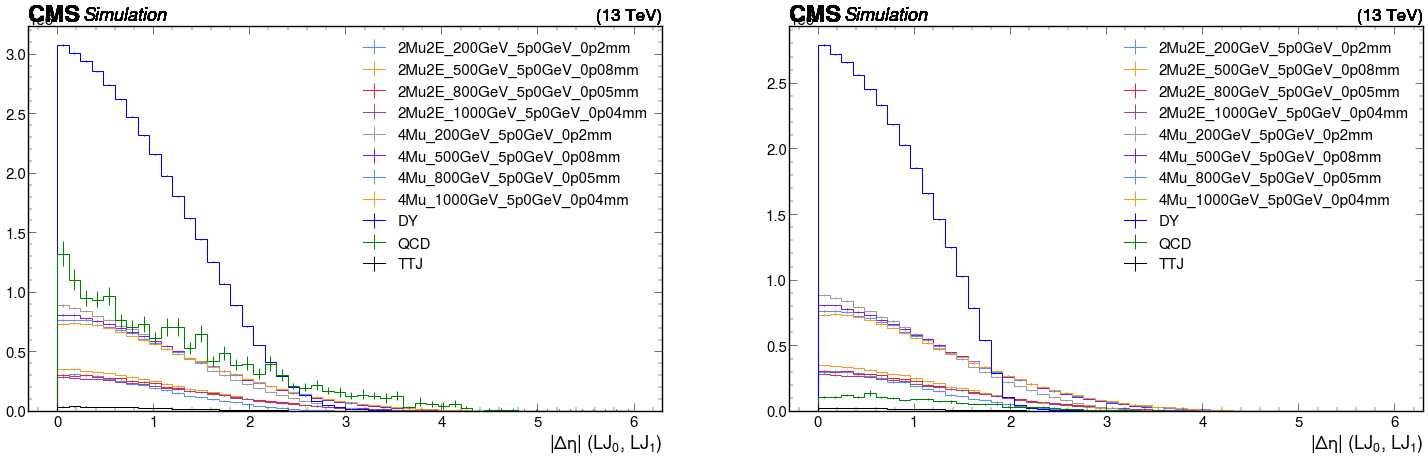

In [9]:
vr = "11"
# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")


#printing cutflows
output_2mu[sig_2mu[2]]["cutflow"][ch2].print_table(unweighted=True)
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

- ### 12: Adding nlj cuts. Running all 2mu2e, 4mu, and 700 bkg files.
- ### 14: Running over all files in all samples

cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection             173803.0     173803.0
pass triggers             68026.0      68026.0
PV filter                173803.0      68026.0


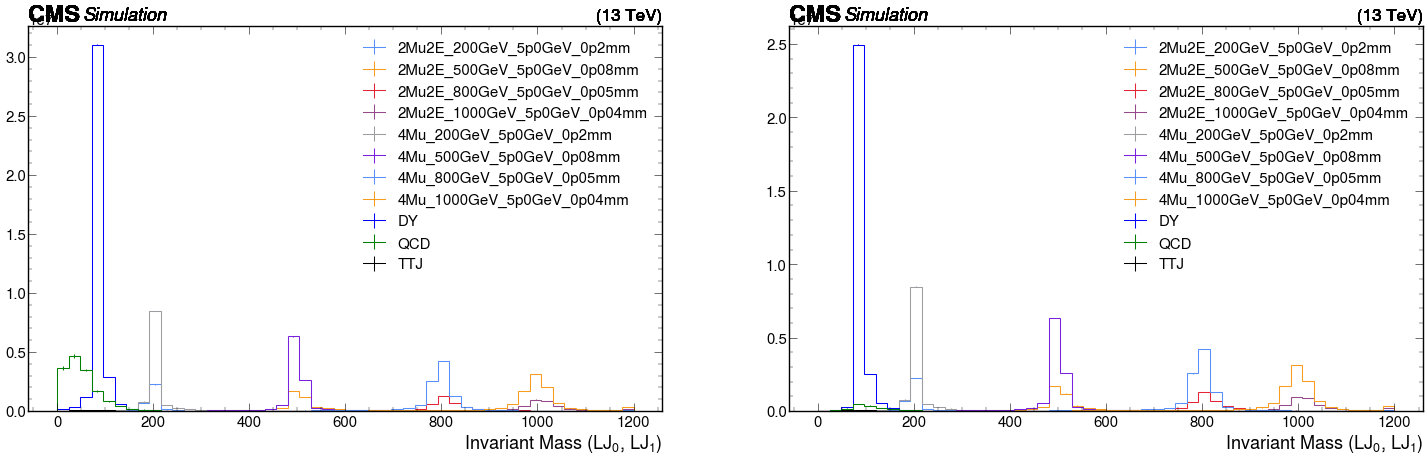

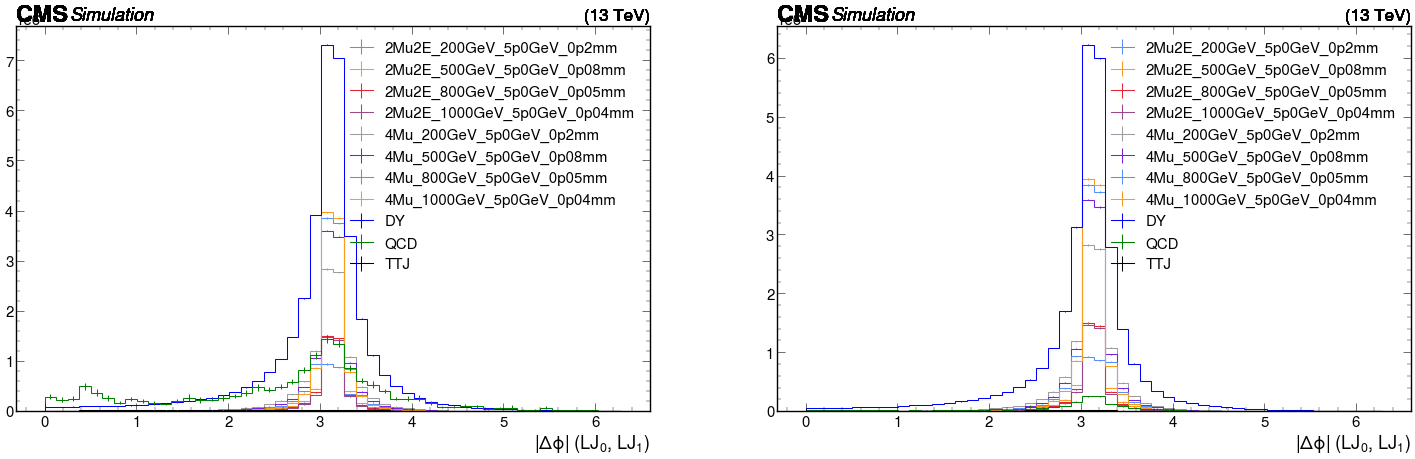

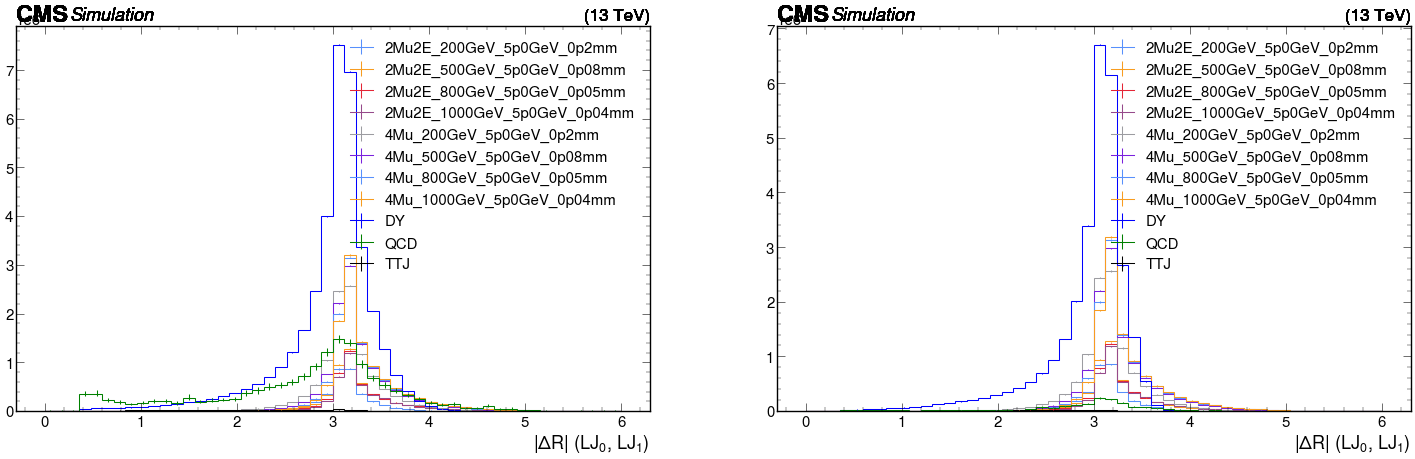

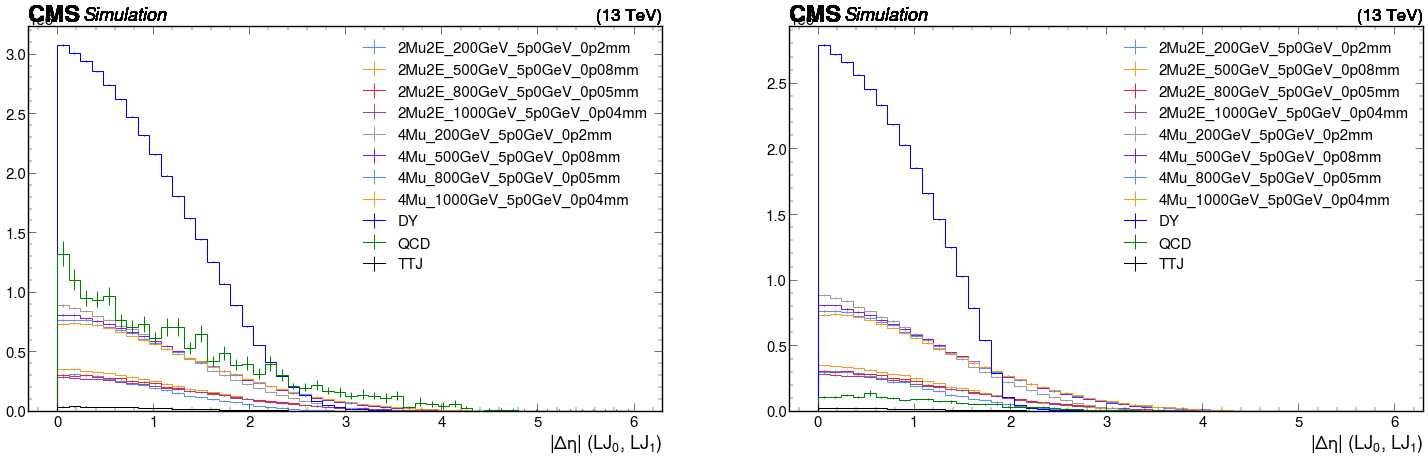

In [10]:
vr = "12" #,  
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj"]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")

#printing cutflows
output_2mu[sig_2mu[2]]["cutflow"][ch2].print_table(unweighted=True)
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

# 13 Adding the $\Delta \Phi$ cut. Settling on 4 2mu, 4mu, and all BKG samples. Running over all files 

cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection             173803.0     173803.0
pass triggers             68026.0      68026.0
PV filter                173803.0      68026.0


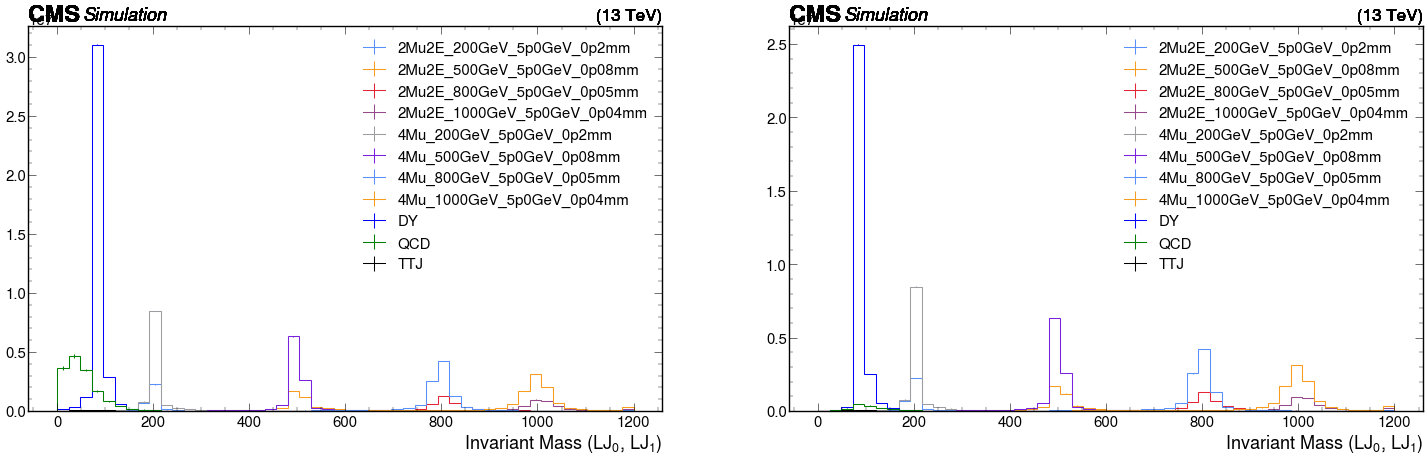

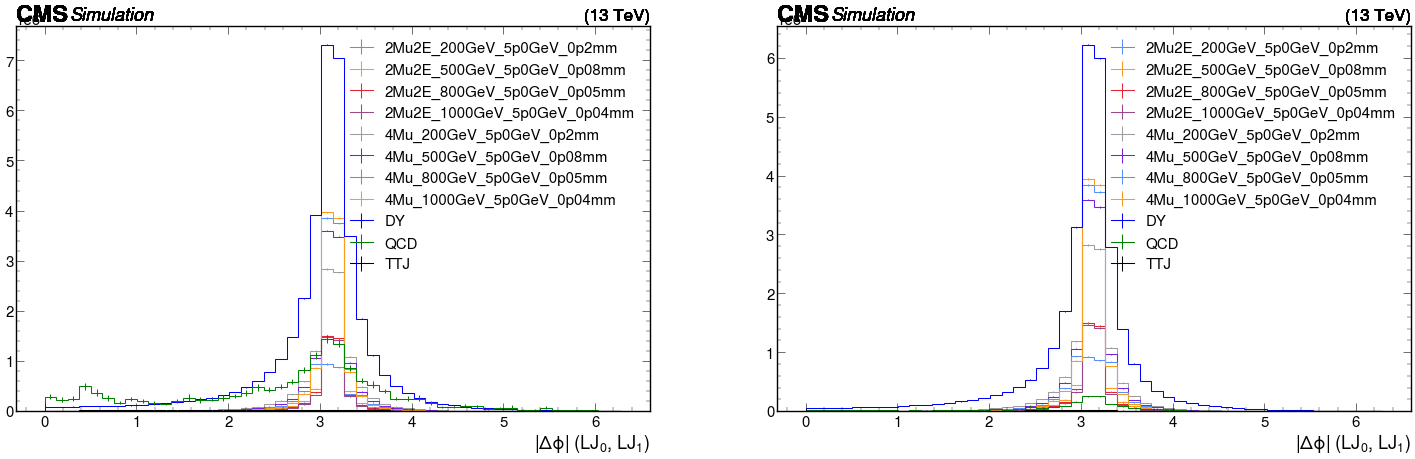

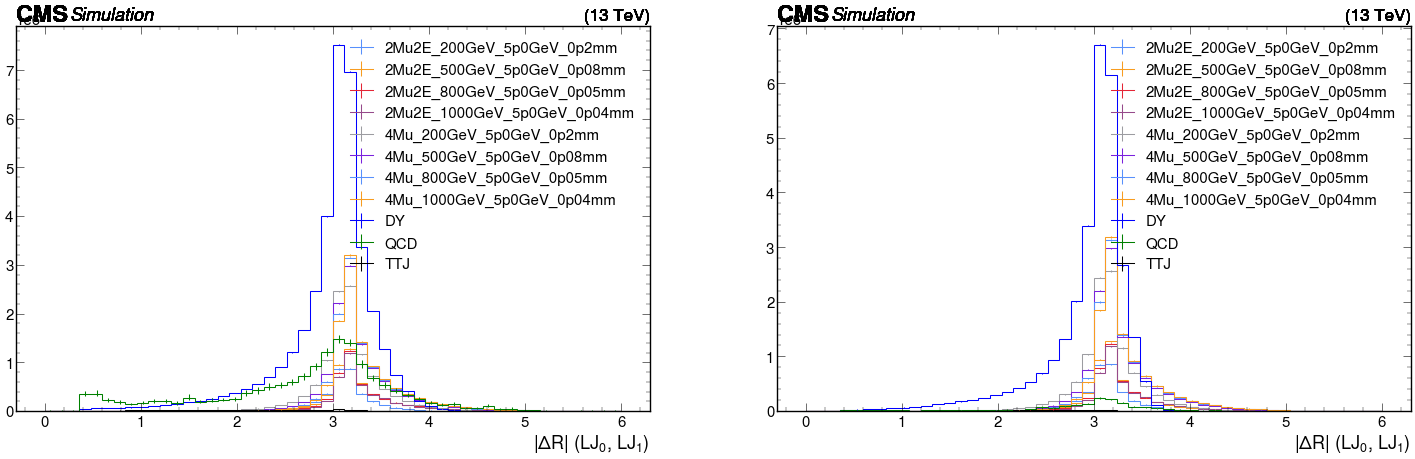

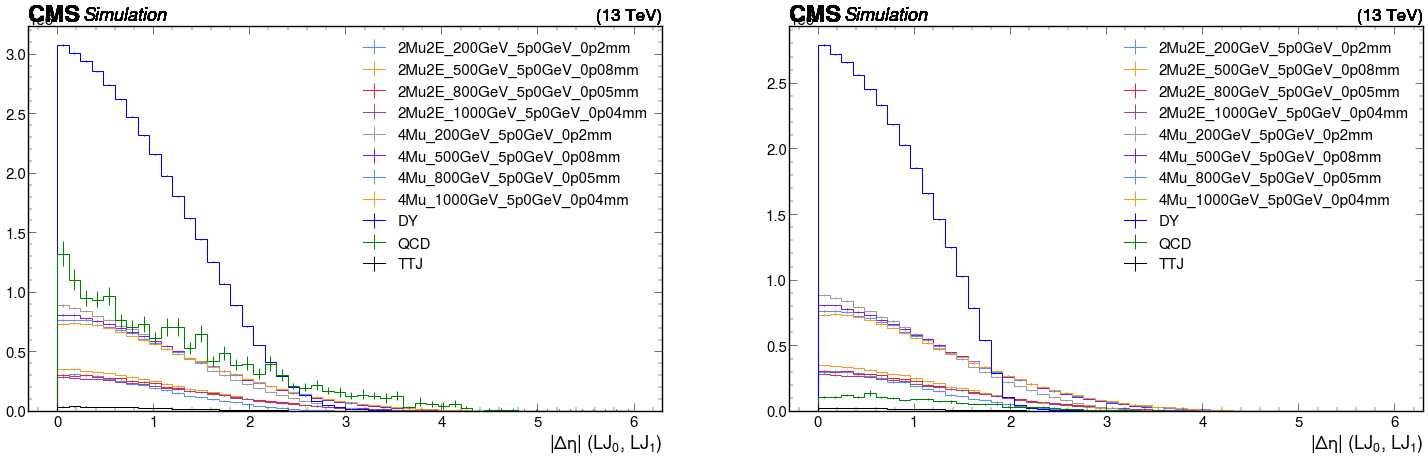

In [10]:
vr = "13"
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2"]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")

#printing cutflows
output_2mu[sig_2mu[2]]["cutflow"][ch2].print_table(unweighted=True)
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

In [ ]:
# test
print(out_all.keys())

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
# LJ quantities

# "lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR""lj_lj_absdeta"
# , "lj_lj_absdR", "lj_lj_invmass"]
hists_to_plot = ["lj_n","lj0_pt", "lj1_pt"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")